# Traffic Accident Analysis
Analyzing Road Traffic Accidents in Ethiopia

**Authors:** Brian Muuo & Sharon Mungai

**Course:** DSA1080

---

**Project Overview** 
- Road traffic accidents(RTAs) are a major public health and safety concern in Ethiopia.

- This project analyzes a real-world traffic accident dataset to identify patterns related to drivers, vehicles, road conditions, weather conditions, and accident severity. Through data cleaning, exploratory data analysis (EDA), and visualization, the project aims to generate insights that can support road safety planning and policy decisions.

**Problem Statement**
- Although traffic accident data is routinely collected, it is often underutilized for decision-making. Many important factors such as driver experience, weather conditions, road conditions, and vehicle characteristics may influence accident severity but are not always analyzed systematically.

- This project seeks to identify the major contributors to traffic accidents and determine the characteristics associated with severe accidents.

**Objectives**
The objectives of this project are to:
 
- Clean and prepare the traffic accident dataset.
- Handle missing values values and inconsistent records.
- Explore accident patterns using descriptive statistics.
- Visualize important trends.
- Identify factors associated with accident severity.
- Provide recommendations based on findings.

**Target Users**
- Road safety authorities, traffic police, urban planners, and insurance companies.

---


## 1. Importing Required Libraries

In [1]:
# Create text file with necessary packages needed for the project
packages= ["pandas>=2.2.0",
           "numpy>=2.0.0",
           "matplotlib>=3.9.0",
           "seaborn>=0.13.2",
           "jupyter>=1.1.0",
           "notebook>=7.0.0"]

with open("../requirements.txt", "w") as file: #..\requirements- creates the txt file one folder up from where the current notebook is in
    file.write("\n".join(packages))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
# Display settings so wide dataframes are easier to read in the notebook

The project uses Pandas for data manipulation, NumPy for numerical operations, and visualization libraries such as Matplotlib and Seaborn.

## 2. Load the Dataset

In [3]:
# change the path of the dataset to your local path where the dataset is stored
df = pd.read_csv("C:\\Users\\user\\Downloads\\USIU_US26\\Traffic_Accident_Analysis\\data\\RTA Dataset.csv") 


The traffic accident dataset is loaded into a Pandas DataFrame for analysis.

An initial inspection is then performed to understand the structure of the dataset before any cleaning operations.

## 3. Preview the Data

In [5]:
# First 5 rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [6]:
# Last 5 rows
df.tail()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,No defect,Outside rural areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Escarpments,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,No defect,Office areas,Undivided Two way,Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury
12315,13:55:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Other,Owner,2-5yrs,No defect,Outside rural areas,Undivided Two way,Tangent road with mountainous terrain and,O Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Stopping,Pedestrian,Female,5,3,Driver,Normal,Crossing from nearside - masked by parked or s...,Changing lane to the right,Slight Injury


- The first and last five rows provide an initial overview of the dataset.

- From these records, we can observe that ```each row represents a single reported road traffic accident```, while ```each column describes a specific characteristic of that accident```, such as the driver, vehicle, road environment, weather conditions, and accident severity.

- Previewing the data also helps us identify obvious formatting issues, unexpected values, or missing information before beginning the cleaning process.

### Data Shape

In [7]:
#dataset shape
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:",cols)

Number of rows: 12316
Number of columns: 32


- The dataset contains **12,316 accident records** and **32 variables**.

- A relatively large number of observations provides enough information to identify meaningful trends and patterns during the analysis. 
The 32 variables capture different aspects of road traffic accidents, including driver characteristics, vehicle information, road conditions, casualty information, and accident outcomes.

### Data Types

In [8]:
#data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

- The dataset contains both numerical and categorical variables.

- Most of the variables are currently stored as **object** data types because they contain text.
- However, not all object variables truly represent text. Some represent categories (such as weather conditions or accident severity), while others represent time.

- Later in the cleaning process, these variables will be converted into more appropriate data types to improve memory usage and make analysis and visualization easier.

### Column Names

In [9]:
columns = df.columns
for index, col in enumerate(columns, start=1): # enumerate is generating a sequence of column names paired up with their index numbers.
    print(f"{index}.{col}")
    # print(str(index) + "." + col)

1.Time
2.Day_of_week
3.Age_band_of_driver
4.Sex_of_driver
5.Educational_level
6.Vehicle_driver_relation
7.Driving_experience
8.Type_of_vehicle
9.Owner_of_vehicle
10.Service_year_of_vehicle
11.Defect_of_vehicle
12.Area_accident_occured
13.Lanes_or_Medians
14.Road_allignment
15.Types_of_Junction
16.Road_surface_type
17.Road_surface_conditions
18.Light_conditions
19.Weather_conditions
20.Type_of_collision
21.Number_of_vehicles_involved
22.Number_of_casualties
23.Vehicle_movement
24.Casualty_class
25.Sex_of_casualty
26.Age_band_of_casualty
27.Casualty_severity
28.Work_of_casuality
29.Fitness_of_casuality
30.Pedestrian_movement
31.Cause_of_accident
32.Accident_severity


The dataset consists of 32 variables describing different aspects of traffic accidents. 

These variables can be grouped into five major categories:

1. **Driver Characteristics:** Age, sex, education, driving experience, and relationship to the vehicle.

2. **Vehicle Characteristics:** Vehicle type, ownership, service years, and mechanical defects.

3. **Road and Environmental Conditions:** Road type, road condition, weather, lighting, junction type, and accident location.

4. **Casualty Information:** Casualty class, age, gender, severity, occupation, and physical fitness.

5. **Accident Information:** Collision type, vehicle movement, number of vehicles involved, number of casualties, cause of accident, and accident severity.

The primary outcome of interest in this project is **Accident Severity**, while the other variables are used as explanatory factors to understand patterns associated with traffic accidents.

### Statistical Description of the Dataset

In [10]:
# summary of all columns(for both categorical and numerical columns)
df.describe(include= "all")

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,7889,12077,11931,12174,11429,12144,12316,12316,12316,12161,12316.000000,12316.000000,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,3,14,7,9,8,5,4,4,9,10,NaN,NaN,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,No defect,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,NaN,NaN,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,7777,3819,4411,10459,4543,11296,9340,8798,10063,8774,NaN,NaN,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.040679,1.548149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.688790,1.007179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- The descriptive statistics provide a summary of the numerical and object variables in the dataset.

- They show the minimum, maximum, average and spread of numerical values such as the number of vehicles involved and the number of casualties.
- They also show the most frequent vlaues of the object variables.

- At this stage, the statistics are mainly used to understand the data and identify values that may require further investigation during cleaning.

## 3. Check for Missing values, duplicates and Unique values

### Check Missing values

In [11]:
missing_vals= df.isna().sum()
missing_percent= ((missing_vals / len(df)) * 100).round(2)

missing_summary= pd.DataFrame({
    "Missing_Count":missing_vals,
    "Missing_Percentage":missing_percent
}).sort_values(by="Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Defect_of_vehicle,4427,35.95
Service_year_of_vehicle,3928,31.89
Work_of_casuality,3198,25.97
Fitness_of_casuality,2635,21.39
Type_of_vehicle,950,7.71
Types_of_Junction,887,7.20
Driving_experience,829,6.73
Educational_level,741,6.02
Vehicle_driver_relation,579,4.70
Owner_of_vehicle,482,3.91


- The missing value summary shows that not every variable was recorded for every accident.

- Some variables contain very few missing values, while others have a huge amount of missing information. This is common in real-world datasets where some information may not have been available or recorded at the time of the accident.

- Before deciding how to handle the missing values, it is important to understand **how much information is missing** and **whether the missing values are likely to affect the analysis**.

### Check for Duplicates

- Duplicate records here refer to identical accident reports appearing more than once in the dataset.

In [12]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# To check if there are any duplicate columns
print(df.columns.duplicated().any())

Number of duplicate rows: 0
False


- The output shows that there are no duplicate observations.

- Therefore, no records needed to be removed, and every row represents a unique accident report.

### Check for uniques values

- Checking for unique values helps in identfying inconsistencies in entries, errors or improper formatting, especially within categorical variables.

In [13]:
for col in columns:
    if df[col].dtype == "object":
        print(f"Unique values in {col}:",df[col].unique())
        print("\n")

Unique values in Time: ['17:02:00' '1:06:00' '14:15:00' ... '7:24:00' '19:18:00' '2:47:00']


Unique values in Day_of_week: ['Monday' 'Sunday' 'Friday' 'Wednesday' 'Saturday' 'Thursday' 'Tuesday']


Unique values in Age_band_of_driver: ['18-30' '31-50' 'Under 18' 'Over 51' 'Unknown']


Unique values in Sex_of_driver: ['Male' 'Female' 'Unknown']


Unique values in Educational_level: ['Above high school' 'Junior high school' nan 'Elementary school'
 'High school' 'Unknown' 'Illiterate' 'Writing & reading']


Unique values in Vehicle_driver_relation: ['Employee' 'Unknown' 'Owner' nan 'Other']


Unique values in Driving_experience: ['1-2yr' 'Above 10yr' '5-10yr' '2-5yr' nan 'No Licence' 'Below 1yr'
 'unknown']


Unique values in Type_of_vehicle: ['Automobile' 'Public (> 45 seats)' 'Lorry (41?100Q)' nan
 'Public (13?45 seats)' 'Lorry (11?40Q)' 'Long lorry' 'Public (12 seats)'
 'Taxi' 'Pick up upto 10Q' 'Stationwagen' 'Ridden horse' 'Other' 'Bajaj'
 'Turbo' 'Motorcycle' 'Special vehicle' 'Bi

During this step, several issues were identified, including:

- inconsistent spelling,
- unnecessary spaces,
- different ways of writing the same category,
- placeholder values such as "Unknown",
- and data entry errors.

Identifying these inconsistencies early ensures that categories representing the same meaning are not treated as separate groups during analysis.

## 4. Feature Selection
Not every variable in the original dataset contributes directly to the objectives of this project.

Columns with limited analytical value or excessive missing information were excluded to reduce noise and simplify the analysis.

The retained variables focus on:

- Driver characteristics
- Vehicle information
- Road environment
- Weather conditions
- Casualty information
- Accident severity

In [14]:
# columns we'll be working with for this project
core_columns = ["Time",
    "Day_of_week",
    "Age_band_of_driver",
    "Sex_of_driver",
    "Driving_experience",
    "Type_of_vehicle",
    "Area_accident_occured",
    "Road_surface_type",
    "Road_surface_conditions",
    "Weather_conditions",
    "Light_conditions",
    "Type_of_collision",
    "Number_of_vehicles_involved",
    "Number_of_casualties",
    "Vehicle_movement",
    "Sex_of_casualty",
    "Age_band_of_casualty",
    "Casualty_severity",
    "Cause_of_accident",
    "Accident_severity"]

# columns we can use for future analysis
optional_columns = ["Owner_of_vehicle",
    "Service_year_of_vehicle",
    "Fitness_of_casuality",
    "Pedestrian_movement"]

df2 = df[core_columns + optional_columns].copy()

In [15]:
rows, cols = df2.shape
print("Number of rows:", rows)
print("Number of columns:",cols)

Number of rows: 12316
Number of columns: 24


A new dataset (`df2`) containing only the most relevant variables was created. This reduces unnecessary complexity while keeping the information needed for meaningful analysis.

## 5. Stanadardize Text Values

- Real-world datasets often contain inconsistent text formatting.

- For example, the same category may appear with leading spaces, extra spaces between words, or different spellings.

- Standardising the text ensures that values representing the same category are grouped together during analysis instead of being counted separately.

### Removing Whitespaces

In [16]:
# Remove (leading and trailing)whitespace from all object columns
object_cols = df2.select_dtypes(include="object").columns

df2[object_cols] = df2[object_cols].apply(lambda col: col.str.strip())

### Fix spelling or formatting errors

In [17]:
# Area Accident occured
df2["Area_accident_occured"] = (df2["Area_accident_occured"].str.strip())

# fix the merged entries
df2["Area_accident_occured"] = df2["Area_accident_occured"].replace({
    "Rural village areasOffice areas":"Rural village areas"
})

In [18]:
# Weather conditions
df2["Weather_conditions"] = df2["Weather_conditions"].replace({
    "Raining":"Rain",
    "Raining and Windy":"Rain & Wind"
})

In [19]:
# Cause of accident
df2["Cause_of_accident"] = df2["Cause_of_accident"].replace({
    "Driving at high speed": "Overspeed",
    "Turnorver":"Overturning"
})



In [20]:
# Casualty Age
def age_to_band(age):
    if pd.isna(age):
        return np.nan

    try:
        age = int(age)

        if age < 18:
            return "Under 18"
        elif age <= 30:
            return "18-30"
        elif age <= 50:
            return "31-50"
        else:
            return "Over 51"

    except ValueError:
        return age
    

df2["Age_band_of_casualty"] = (df2["Age_band_of_casualty"].apply(age_to_band))

In [21]:
# Fitness of casualty
df2["Fitness_of_casuality"] = df2["Fitness_of_casuality"].replace({
    "NormalNormal":"Normal"
})

In [22]:
# Casualty Severity Labels mapping
severity={"1":"Fatal Injury",
          "2":"Serious Injury",
          "3":"Slight Injury"}

df2["Casualty_severity_label"]=(df2["Casualty_severity"].astype(str).map(severity))

In [23]:
# Fix errors in Type of vehicle column
df2["Type_of_vehicle"] = (df2["Type_of_vehicle"].str.replace("?", "-", regex=False))

### Verify

In [24]:
for col in df2.select_dtypes(include="object").columns:
    print(f"\n{col}({df2[col].nunique(dropna=True)}unique values)")
    print(sorted(df2[col].dropna().unique())) # sorted()-sorts values alphabetically


Time(1074unique values)
['0:01:00', '0:02:00', '0:03:00', '0:04:00', '0:06:00', '0:08:00', '0:09:00', '0:10:00', '0:11:00', '0:15:00', '0:17:00', '0:18:00', '0:19:00', '0:20:00', '0:21:00', '0:23:00', '0:25:00', '0:26:00', '0:28:00', '0:29:00', '0:30:00', '0:31:00', '0:34:00', '0:35:00', '0:36:00', '0:40:00', '0:41:00', '0:43:00', '0:44:00', '0:45:00', '0:47:00', '0:50:00', '0:51:00', '0:52:00', '0:53:00', '0:54:00', '0:55:00', '0:56:00', '0:57:00', '10:00:00', '10:01:00', '10:02:00', '10:04:00', '10:05:00', '10:07:00', '10:08:00', '10:10:00', '10:11:00', '10:12:00', '10:13:00', '10:15:00', '10:16:00', '10:17:00', '10:18:00', '10:19:00', '10:20:00', '10:21:00', '10:22:00', '10:23:00', '10:24:00', '10:25:00', '10:26:00', '10:27:00', '10:29:00', '10:30:00', '10:31:00', '10:32:00', '10:34:00', '10:35:00', '10:36:00', '10:37:00', '10:38:00', '10:39:00', '10:40:00', '10:41:00', '10:42:00', '10:43:00', '10:44:00', '10:45:00', '10:47:00', '10:48:00', '10:49:00', '10:50:00', '10:51:00', '10:5

- After standardisation, the unique values were checked again to confirm that inconsistent spellings, unnecessary spaces and formatting issues had been successfully corrected.

- This step ensures that the dataset is clean before proceeding to data type conversion and missing value handling.

## 6.  Convert to Right data types

Variables are converted into appropriate data types to improve both the efficiency and accuracy of the analysis. 

For example: 
- Time values can now be grouped by hour.
- Numerical variables can be used in mathematical calculations.
- Categorical variables are easier to summarize and visualize.


**The following conversions are performed:**

- Time  to datetime/time
- Categorical variables to category
- Numerical variables to integer

### Convert To Time Type

In [25]:
df2["Time"]= (pd.to_datetime(df2["Time"],
                             format= "%H:%M:%S",
                             errors="coerce")
                             .dt.time)

In [26]:
df2["Time"].head()

0    17:02:00
1    17:02:00
2    17:02:00
3    01:06:00
4    01:06:00
Name: Time, dtype: object

### Convert To numeric Type

In [27]:
# INTEGER
numeric_columns = ["Number_of_vehicles_involved", "Number_of_casualties"]

for col in numeric_columns:
    df2[col] = (pd.to_numeric(df2[col],
            errors="coerce").astype("Int64"))
    print(df2[col].head())

0    2
1    2
2    2
3    2
4    2
Name: Number_of_vehicles_involved, dtype: Int64
0    2
1    2
2    2
3    2
4    2
Name: Number_of_casualties, dtype: Int64


### Convert To categorical Type

In [28]:
for col in df2.select_dtypes(include="object").columns:
    if col != "Time" :
        df2[col] = df2[col].astype("category")
print(df2.dtypes)

Time                             object
Day_of_week                    category
Age_band_of_driver             category
Sex_of_driver                  category
Driving_experience             category
Type_of_vehicle                category
Area_accident_occured          category
Road_surface_type              category
Road_surface_conditions        category
Weather_conditions             category
Light_conditions               category
Type_of_collision              category
Number_of_vehicles_involved       Int64
Number_of_casualties              Int64
Vehicle_movement               category
Sex_of_casualty                category
Age_band_of_casualty           category
Casualty_severity              category
Cause_of_accident              category
Accident_severity              category
Owner_of_vehicle               category
Service_year_of_vehicle        category
Fitness_of_casuality           category
Pedestrian_movement            category
Casualty_severity_label        category


The updated data types confirm that each variable is now stored in a format appropriate for analysis and visualization.

## 7. Ordering Ordinal variables

In [29]:
from pandas.api.types import CategoricalDtype

# Day of Week
day_order= CategoricalDtype(categories=["Sunday",
                                        "Monday",
                                        "Tuesday",
                                        "Wednesday",
                                        "Thursday",
                                        "Friday"],
                                        ordered=True)
df2["Day_of_week"]=(df2['Day_of_week'].astype(day_order))


# Age bands
age_order= CategoricalDtype(categories=["Under 18",
                                        "18-30",
                                        "31-50",
                                        "Over 51"], ordered=True)

df2["Age_band_of_casualty"]=(df2["Age_band_of_casualty"].astype(age_order))
df2["Age_band_of_driver"]=(df2["Age_band_of_driver"].astype(age_order))


# Driving Experience
experience_order= CategoricalDtype(categories=["No License",
                                               "Below 1yr",
                                               "1-2yr",
                                               "2-5yr",
                                               "5-10yr",
                                               "Above 10yr"],
                                               ordered=True)

df2["Driving_experience"]=(df2["Driving_experience"].astype(experience_order))


# Service year of vehicle
service_yr_order= CategoricalDtype(categories=["Below 1yr",
                                               "1-2yr",
                                               "2-5yrs",
                                               "5-10yrs",
                                               "Above 10yr"],
                                               ordered=True)

df2["Service_year_of_vehicle"]=(df2["Service_year_of_vehicle"].astype(service_yr_order))


# Accident Severity
severity_order= CategoricalDtype(categories=["Slight Injury", 
                                 "Serious Injury",
                                 "Fatal Injury"],
                                 ordered=True)

df2["Accident_severity"]=(df2["Accident_severity"].astype(severity_order))

In [30]:
df2.dtypes

Time                             object
Day_of_week                    category
Age_band_of_driver             category
Sex_of_driver                  category
Driving_experience             category
Type_of_vehicle                category
Area_accident_occured          category
Road_surface_type              category
Road_surface_conditions        category
Weather_conditions             category
Light_conditions               category
Type_of_collision              category
Number_of_vehicles_involved       Int64
Number_of_casualties              Int64
Vehicle_movement               category
Sex_of_casualty                category
Age_band_of_casualty           category
Casualty_severity              category
Cause_of_accident              category
Accident_severity              category
Owner_of_vehicle               category
Service_year_of_vehicle        category
Fitness_of_casuality           category
Pedestrian_movement            category
Casualty_severity_label        category


## 8. Handling Missing values

#### Why are Missing Values Important?

- Missing values are common in real-world datasets because some information **may not have been recorded**, **may have been unavailable**, or **may not apply to a particular accident**.

- Ignoring missing values can produce misleading results or even cause errors during analysis.

In [31]:
missing_vals= df2.isna().sum()
missing_percent= ((missing_vals / len(df2)) * 100).round(2)

missing_summary= pd.DataFrame({
    "Missing_Count":missing_vals,
    "Missing_Percentage":missing_percent
}).sort_values(by="Missing_Count", ascending=False)

print(missing_summary)
df2.shape

                             Missing_Count  Missing_Percentage
Service_year_of_vehicle               6811               55.30
Casualty_severity_label               4443               36.08
Age_band_of_casualty                  4443               36.08
Fitness_of_casuality                  2635               21.39
Day_of_week                           1666               13.53
Age_band_of_driver                    1548               12.57
Driving_experience                     980                7.96
Type_of_vehicle                        950                7.71
Owner_of_vehicle                       482                3.91
Vehicle_movement                       308                2.50
Area_accident_occured                  239                1.94
Road_surface_type                      172                1.40
Accident_severity                      158                1.28
Type_of_collision                      155                1.26
Pedestrian_movement                      0             

(12316, 25)

- Variables such as **Service_year_of_vehicle** contained a large proportion of missing values, while many other variables had only a small percentage of missing observations.

- Different imputation strategies were therefore applied depending on:
    1. The percentage of missing values,
    2. The importance of the variable,
    3. The meaning of the missing information.

- This approach helps preserve as much useful information as possible while improving the quality of the dataset.

### Missing values less than / equal to 15%

#### Fill in with mode values

In [32]:
# select cols with >0% and <=15% missing values
mode_cols=missing_summary[(missing_summary["Missing_Percentage"]> 0) & (missing_summary["Missing_Percentage"]<= 15)].index

for col in mode_cols:
    df2[col]= df2[col].fillna(df2[col].mode()[0])

    

#### Why use the Mode?

- Variables with **15% or fewer missing values** contain relatively little missing information.

- Removing these rows would unnecessarily reduce the size of the dataset. Instead, the missing values were replaced with the **most frequently occurring category (the mode).**

- Using the mode is appropriate because these variables are categorical, and replacing a small number of missing values with the most common response is unlikely to significantly change the overall distribution of the data.

### Missing values greater than 15% and less than 40%

#### Fill null values with placeholder "No Casualty"

In [33]:
# Casualty related columns with >15% and <40% missing values

# Sex of casualty
df2["Sex_of_casualty"] = (df2["Sex_of_casualty"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Age band of casualty
df2["Age_band_of_casualty"] = (df2["Age_band_of_casualty"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Casualty Severity
df2["Casualty_severity"] = (df2["Casualty_severity"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Casualty severity labels
df2["Casualty_severity_label"] = (df2["Casualty_severity_label"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

# Fitness of casualty
df2["Fitness_of_casuality"] = (df2["Fitness_of_casuality"]
        .cat.add_categories("No Casualty")
        .fillna("No Casualty"))

#### Why create meaningful categories?

- Several casualty-related variables contained between **15% and 40% missing values**.

- Rather than replacing these values with the most common category, we considered the context of the dataset.

- Many accidents did not involve a casualty, meaning that information such as casualty age, sex, or injury severity simply did not exist.

- Therefore, instead of treating these records as missing, they were assigned meaningful categories such as **"No Casualty"** where appropriate.

- This preserves valuable accident records while making the dataset easier to interpret during analysis.

### Missing values greater than 40% 

#### Fill null value with placeholder "Unknown"

In [34]:
# Keep missing values as their own category
df2["Service_year_of_vehicle"] = (df2["Service_year_of_vehicle"]
        .cat.add_categories("Unknown")
        .fillna("Unknown"))

### Why keep "Unknown"?

- The variable **Service_year_of_vehicle** contained more than half of its observations missing.

- Removing the variable would result in the loss of potentially useful information, while replacing the missing values with the most common category could introduce bias.

- Instead, the missing values were assigned the category **"Unknown"**.

- This approach allows the variable to remain available for future analysis while clearly indicating that the service year was not recorded.

In [35]:
df2.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Driving_experience             0
Type_of_vehicle                0
Area_accident_occured          0
Road_surface_type              0
Road_surface_conditions        0
Weather_conditions             0
Light_conditions               0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Cause_of_accident              0
Accident_severity              0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Fitness_of_casuality           0
Pedestrian_movement            0
Casualty_severity_label        0
dtype: int64

- After applying the appropriate missing value strategies to each variable, the cleaned dataset contains no remaining missing values in the selected variables.

- Different imputation methods were chosen based on the nature of each variable rather than using a single method for the entire dataset.

- This produces a cleaner and more reliable dataset for exploratory data analysis.

## 9. Export the Dataset

In [36]:
try:
    df2.to_csv("C:/Users/user/Downloads/cleaned_rta_data.csv", index=False)
except NameError:
    df2 = df[core_columns + optional_columns].copy()
    df2.to_csv("C:/Users/user/Downloads/cleaned_rta_data.csv", index=False)

- The cleaned dataset is saved as a CSV file and is now ready for exploratory data analysis (EDA).
- Saving the cleaned data ensures that future analyses can begin directly from the prepared dataset without repeating the entire cleaning process.

- It also creates a permanent record of the preprocessing steps completed during this stage of the project.

- **Cleaning activities completed include:**

1. ```Feature selection```: selected the variables relevant to the project objectives.
2. ```Text standardization```: Standardized text values by removing unnecessary spaces and correcting inconsistent labels.
3. ```Missing value handling```: handled missing values using different methods based on the percentage and meaning of the missing data.
4. ```Data type conversion```: converted variables into appropriate data types.
5. ```Removal of inconsistencies```: corrected data entry errors.

- The cleaned dataset is exported for exploratory data analysis.

## 10. Exploratory Data Analysis

- After cleaning and preparing the dataset, the next step is to explore it in order to understand the characteristics of road traffic accidents.

- Exploratory Data Analysis (EDA) helps identify patterns, trends and relationships between different variables without making assumptions beforehand.

- The analysis is divided into three sections:

    1. **Univariate Analysis**, which examines one variable at a time.
    2. **Bivariate Analysis**, which investigates the relationship between two variables.
    3. **Multivariate Analysis**, which explores interactions among three or more variables.

The findings from this section will be used to answer the project's analysis questions: 

    1. How many traffic accidents were recorded?
    2. Which locations experience the most accidents?
    3. Which months record the highest number of accidents?
    4. Which days of the week have the highest accident frequency?
    5. What are the leading causes of accidents?
    6. Which weather conditions are associated with accidents?
    7. What is the distribution of accident severity?
    8. Which vehicle types are most involved in accidents?
    9. Which road users are most affected?

Q1: HOW MANY ACCIDENTS WERE RECORDED ?

In [37]:
# Summary statistic: total row count = total recorded accidents
total_accidents = len(df2)
print(f"Total traffic accidents recorded: {total_accidents}")

Total traffic accidents recorded: 12316


Q2: WHICH LOCATIONS EXPERIENCED THE MOST ACCIDENTS ?

In [38]:
# value_counts + sorting: rank accident locations
location_counts = (df2["Area_accident_occured"]
                    .value_counts()
                    .sort_values(ascending=False))

location_table = location_counts.head(10).rename("Accident_Count").to_frame()
location_table

,Accident_Count
Area_accident_occured,
Other,4058
Office areas,3451
Residential areas,2060
Church areas,1060
Industrial areas,456
School areas,415
Recreational areas,328
Outside rural areas,218
Hospital areas,121


C:\Users\user\AppData\Local\Temp\ipykernel_17476\1604195868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_table["Accident_Count"], y=location_table.index, palette="viridis")


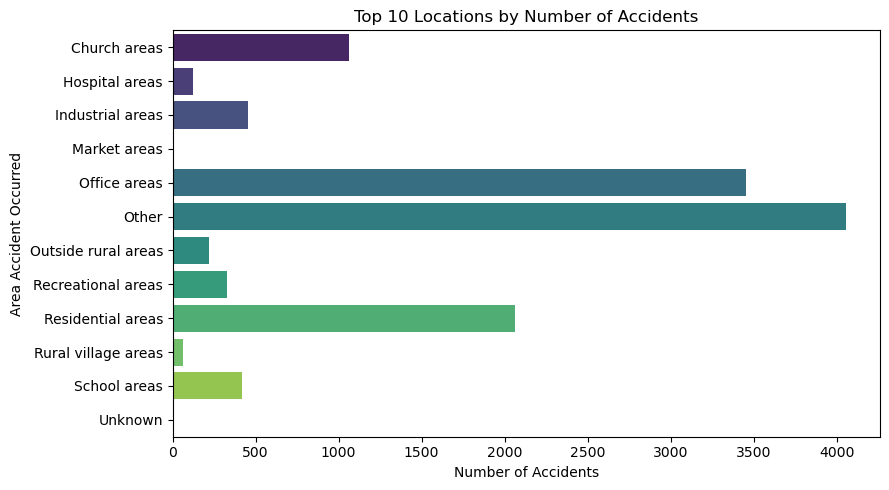

In [39]:
# Visual: top 10 accident locations
plt.figure(figsize=(9,5))
sns.barplot(x=location_table["Accident_Count"], y=location_table.index, palette="viridis")
plt.title("Top 10 Locations by Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Area Accident Occurred")
plt.tight_layout()
plt.show()

Q3 : ACCIDENTS BY HOUR OF DAY ?

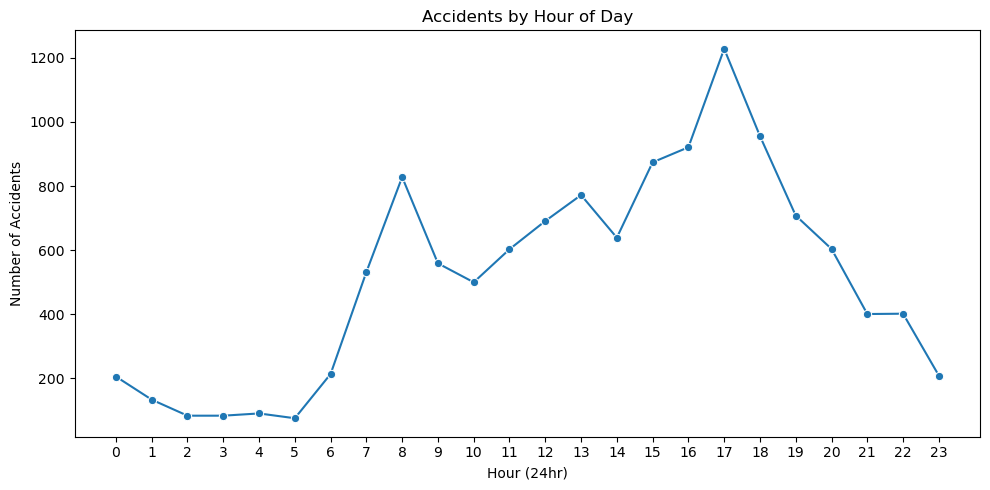

In [40]:
# Extract hour from Time, then group + aggregate (count) by hour
df2["Hour"] = df2["Time"].apply(lambda t: t.hour if pd.notna(t) else np.nan)

hourly_counts = (df2.groupby("Hour", observed=True)
                  .size()
                  .sort_values(ascending=False))

hourly_table = hourly_counts.rename("Accident_Count").to_frame()
hourly_table.head(10)


# Visual: accidents across all 24 hours, in time order (not sorted by count)
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_counts.sort_index().index, y=hourly_counts.sort_index().values, marker="o")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour (24hr)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

Q4: WHICH DAYS OF THE WEEK HAVE THE HIGHEST ACCIDENT FREQUENCY ?

C:\Users\user\AppData\Local\Temp\ipykernel_17476\3133040742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_table.index, y=day_table["Accident_Count"], order=day_table.index, palette="mako")


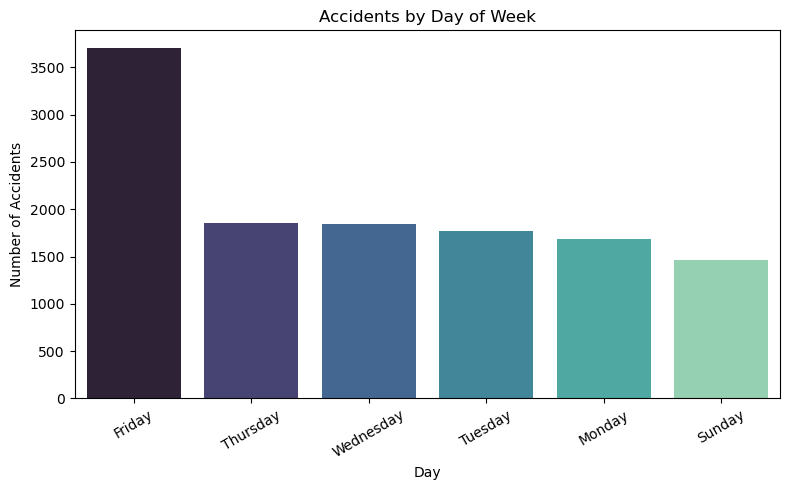

In [41]:
# value_counts on an ordered categorical column
day_counts = df2["Day_of_week"].value_counts().sort_values(ascending=False)
day_table = day_counts.rename("Accident_Count").to_frame()
day_table



plt.figure(figsize=(8,5))
sns.barplot(x=day_table.index, y=day_table["Accident_Count"], order=day_table.index, palette="mako")
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Q5: WHAT ARE THE LEADING CAUSES OF ACCIDENTS ?

C:\Users\user\AppData\Local\Temp\ipykernel_17476\4284040.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cause_table["Accident_Count"], y=cause_table.index, palette="rocket")


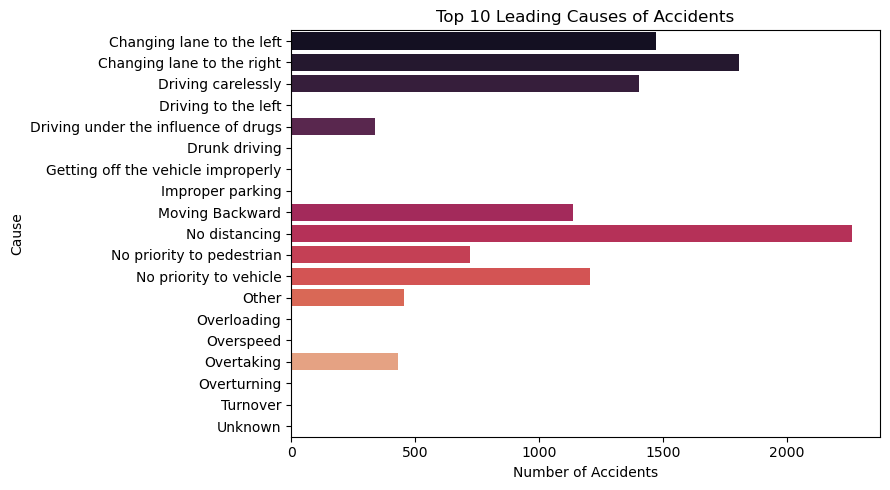

In [42]:
cause_counts = (df2["Cause_of_accident"]
                 .value_counts()
                 .sort_values(ascending=False))
cause_table = cause_counts.head(10).rename("Accident_Count").to_frame()
cause_table


plt.figure(figsize=(9,5))
sns.barplot(x=cause_table["Accident_Count"], y=cause_table.index, palette="rocket")
plt.title("Top 10 Leading Causes of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause")
plt.tight_layout()
plt.show()

Q6: WHAT WEATHER CONDITIONS ARE ASSSOCIATED WITH ACCIDENTS ?

In [43]:
weather_counts = df2["Weather_conditions"].value_counts().sort_values(ascending=False)
weather_table = weather_counts.rename("Accident_Count").to_frame()
weather_table


# Grouping + aggregation: severity breakdown within each weather condition
weather_severity = (df2.groupby("Weather_conditions", observed=True)["Accident_severity"]
                     .value_counts()
                     .unstack(fill_value=0))
weather_severity

Accident_severity,Slight Injury,Serious Injury,Fatal Injury
Weather_conditions,,,
Cloudy,117,8,0
Fog or mist,9,1,0
Normal,8589,1474,0
Other,268,28,0
Rain,1173,158,0
Rain & Wind,38,2,0
Snow,56,5,0
Unknown,241,51,0
Windy,82,16,0


Q7: WHAT IS THE DISTRIBUTION OFACCIDENT SEVERITY ?

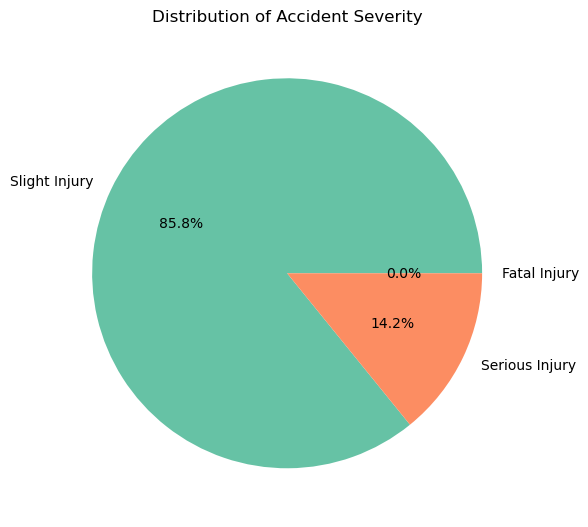

In [44]:
# value_counts with percentages (summary statistic)
severity_counts = df2["Accident_severity"].value_counts()
severity_percent = (severity_counts / severity_counts.sum() * 100).round(2)

severity_table = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": severity_percent
})
severity_table


plt.figure(figsize=(6,6))
plt.pie(severity_table["Count"], labels=severity_table.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2"))
plt.title("Distribution of Accident Severity")
plt.tight_layout()
plt.show()

Q8. Which vehicle types are most involved in accidents ?

C:\Users\user\AppData\Local\Temp\ipykernel_17476\1492917934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_table["Accident_Count"], y=vehicle_table.index, palette="flare")


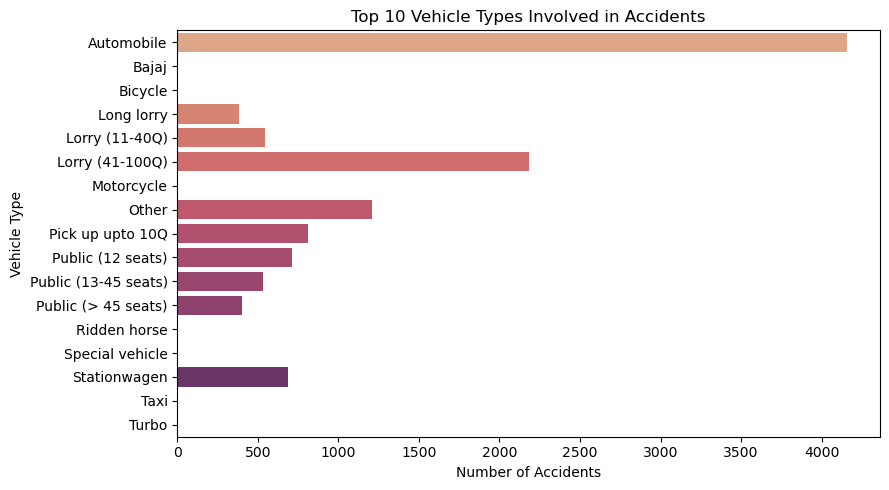

In [45]:
vehicle_counts = (df2["Type_of_vehicle"]
                   .value_counts()
                   .sort_values(ascending=False))
vehicle_table = vehicle_counts.head(10).rename("Accident_Count").to_frame()
vehicle_table


plt.figure(figsize=(9,5))
sns.barplot(x=vehicle_table["Accident_Count"], y=vehicle_table.index, palette="flare")
plt.title("Top 10 Vehicle Types Involved in Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show()

Q9. Which road users are most affected?

In [46]:
# Filtering example: isolate only fatal-injury casualties
fatal_casualties = df2[df2["Casualty_severity_label"] == "Fatal Injury"]

print(f"Total fatal-injury casualty records: {len(fatal_casualties)}")

# value_counts on who is affected (sex + age band of casualty)
sex_counts = df2["Sex_of_casualty"].value_counts()
age_counts = df2["Age_band_of_casualty"].value_counts().sort_index()

print("\nCasualties by sex:")
print(sex_counts)
print("\nCasualties by age band:")
print(age_counts)


# Grouping + aggregation: casualty severity breakdown by age band
age_severity = (df2.groupby("Age_band_of_casualty", observed=True)["Casualty_severity_label"]
                 .value_counts()
                 .unstack(fill_value=0))
age_severity




Total fatal-injury casualty records: 26

Casualties by sex:
Sex_of_casualty
Male           5253
na             4443
Female         2620
No Casualty       0
Name: count, dtype: int64

Casualties by age band:
Age_band_of_casualty
Under 18       1279
18-30          3145
31-50          2455
Over 51         994
No Casualty    4443
Name: count, dtype: int64


Casualty_severity_label,Fatal Injury,Serious Injury,Slight Injury,No Casualty
Age_band_of_casualty,,,,
Under 18,7,143,1129,0
18-30,5,275,2865,0
31-50,4,214,2237,0
Over 51,10,139,845,0
No Casualty,0,0,0,4443
